# Exp 31 — Occlusion saliency: what makes the model say "octopus"

Clip: `data/octopus_clips_verified/2026-02-20/182422/Right_Front_1289-1309.mp4`

1. Sample the clip, classify every frame with the letterbox CLIP+MLP model.
2. Take the **highest-confidence** frames.
3. **Occlusion saliency**: slide a gray patch over the image; wherever hiding it makes
   `p_visible` drop the most = the region the model relies on to call it "octopus visible".


In [1]:
import json, subprocess, tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from PIL import Image

PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents]
               if (p/"data").exists() and (p/"weights").exists())
CLIP_MP4 = PROJECT/"data/octopus_clips_verified/2026-02-20/182422/Right_Front_1289-1309.mp4"
CKPT     = PROJECT/"weights/clip_mlp_letterbox_v1.pt"
OUT      = PROJECT/"data"/"saliency"; OUT.mkdir(parents=True, exist_ok=True)
import sys as _sys
from pathlib import Path as _P
_root = next(p for p in [_P.cwd(), *_P.cwd().parents] if (p / 'server_creds.py').exists())
_sys.path.insert(0, str(_root))   # repo root, wherever this nb is run from
from server_creds import USER, PASS as PWD  # creds from env / .env, not hardcoded
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print("clip exists:", CLIP_MP4.exists(), "| device:", device)

def letterbox(img, size=224, fill=(128,128,128)):
    w,h=img.size; s=size/max(w,h); nw,nh=max(1,round(w*s)),max(1,round(h*s))
    img=img.resize((nw,nh),Image.BICUBIC)
    cv=Image.new("RGB",(size,size),fill); cv.paste(img,((size-nw)//2,(size-nh)//2)); return cv

# ---- load CLIP + MLP ----
try:
    import pkg_resources, packaging, packaging.version, packaging.specifiers, packaging.requirements
    pkg_resources.packaging=packaging
except Exception: pass
import clip as clip_lib
ck=torch.load(CKPT,map_location=device)
clip_model,preprocess=clip_lib.load(ck["clip_model"],device=device); clip_model.eval()
feat=ck["feat_dim"]; arch=ck["arch"]; hid=[int(x) for x in arch.replace("mlp_","").split("_")]; dims=[feat]+hid+[2]
L=[]
for i in range(len(dims)-1):
    L.append(nn.Linear(dims[i],dims[i+1]))
    if i<len(dims)-2: L+=[nn.ReLU(),nn.Dropout(0.3)]
classifier=nn.Sequential(*L).to(device); classifier.load_state_dict(ck["state_dict"]); classifier.eval()
vis_idx=ck.get("label_map",{}).get("visible",1)
print(f"model: {ck['clip_model']}+{arch}  acc={ck.get('test_acc',0):.1%}  visible=idx{vis_idx}")

def p_visible_tensor(x):  # x: (N,3,224,224) normalised
    with torch.no_grad():
        f=clip_model.encode_image(x).float(); f=f/f.norm(dim=-1,keepdim=True)
        return torch.softmax(classifier(f),dim=1)[:,vis_idx]

clip exists: True | device: mps


/var/folders/4x/8gdbr2c547b7s8k94zw4rwmh0000gn/T/ipykernel_84961/2327889026.py:24: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources, packaging, packaging.version, packaging.specifiers, packaging.requirements


model: ViT-B/32+mlp_256_64  acc=96.9%  visible=idx1


In [2]:
# ---- sample clip, classify, pick highest-confidence frames ----
SAMPLE_FPS=2
with tempfile.TemporaryDirectory() as t:
    subprocess.run(["ffmpeg","-loglevel","error","-i",str(CLIP_MP4),
                    "-vf",f"fps={SAMPLE_FPS}","-q:v","2",f"{t}/f_%03d.jpg"],check=True)
    frame_paths=sorted(Path(t).glob("f_*.jpg"))
    frames=[Image.open(f).convert("RGB") for f in frame_paths]

batch=torch.stack([preprocess(letterbox(im)) for im in frames]).to(device)
probs=p_visible_tensor(batch).cpu().numpy()
print(f"{len(frames)} frames @ {SAMPLE_FPS}fps   p_visible: min={probs.min():.3f} max={probs.max():.3f} mean={probs.mean():.3f}")

K=3
top_idx=np.argsort(probs)[::-1][:K]
print("highest-confidence frames (idx, t_sec, p_visible):")
for r in top_idx: print(f"  frame {r:02d}  t={r/SAMPLE_FPS:.1f}s  p={probs[r]:.4f}")

40 frames @ 2fps   p_visible: min=0.012 max=0.999 mean=0.873
highest-confidence frames (idx, t_sec, p_visible):
  frame 36  t=18.0s  p=0.9991
  frame 22  t=11.0s  p=0.9989
  frame 18  t=9.0s  p=0.9988


In [3]:
# ---- occlusion saliency ----
def occlusion_saliency(img_pil, window=32, stride=16):
    x = preprocess(letterbox(img_pil)).to(device)          # (3,224,224) normalised
    p0 = p_visible_tensor(x.unsqueeze(0)).item()
    H=W=224
    occ=[]; coords=[]
    for y in range(0, H-window+1, stride):
        for xx in range(0, W-window+1, stride):
            xo=x.clone(); xo[:, y:y+window, xx:xx+window]=0.0   # 0 = dataset mean (gray)
            occ.append(xo); coords.append((y,xx))
    sal=np.zeros((H,W),np.float32); cnt=np.zeros((H,W),np.float32)
    for i in range(0,len(occ),64):
        p=p_visible_tensor(torch.stack(occ[i:i+64])).cpu().numpy()
        for (y,xx),pp in zip(coords[i:i+64],p):
            sal[y:y+window,xx:xx+window]+=(p0-pp); cnt[y:y+window,xx:xx+window]+=1
    return p0, sal/np.maximum(cnt,1)

# letterboxed RGB (what the model sees) for display
def lb_array(img): return np.asarray(letterbox(img))

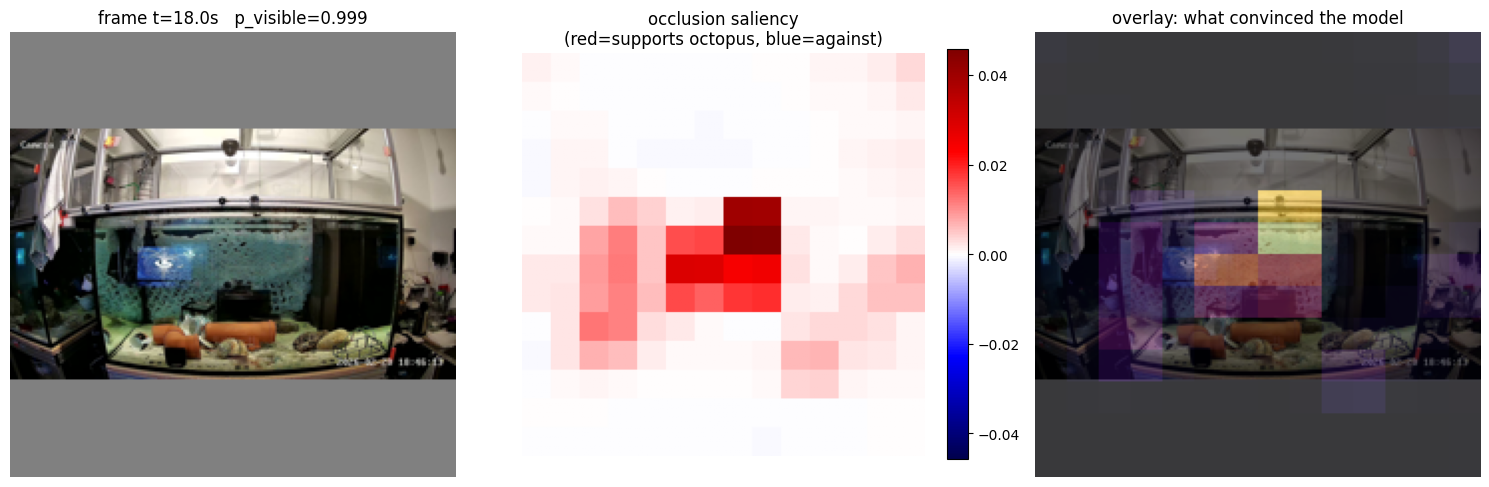

saved saliency_rank1_t18s.png  | hottest region (x,y) norm: (np.float64(0.5), np.float64(0.43))


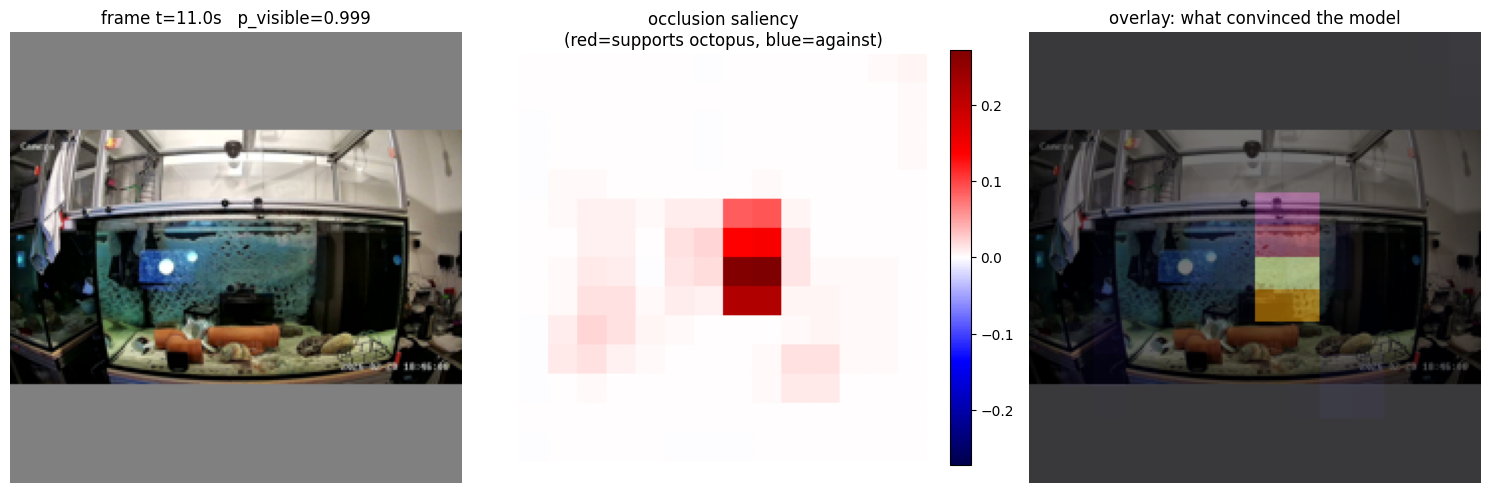

saved saliency_rank2_t11s.png  | hottest region (x,y) norm: (np.float64(0.57), np.float64(0.5))


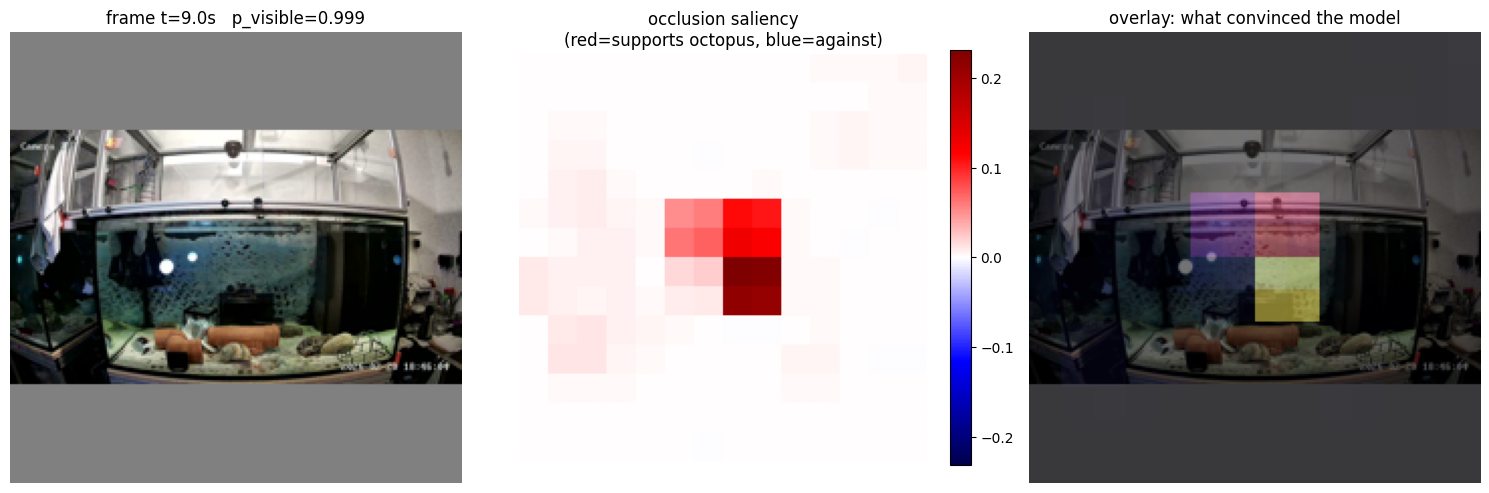

saved saliency_rank3_t9s.png  | hottest region (x,y) norm: (np.float64(0.5), np.float64(0.5))


In [4]:
# ---- run on top frames + visualise ----
for rank,r in enumerate(top_idx,1):
    img=frames[r]; p0,sal=occlusion_saliency(img)
    base=lb_array(img)
    pos=np.clip(sal,0,None)                  # regions that SUPPORT "visible"
    pos=pos/ (pos.max()+1e-8)
    fig,ax=plt.subplots(1,3,figsize=(15,5))
    ax[0].imshow(base); ax[0].set_title(f"frame t={r/SAMPLE_FPS:.1f}s   p_visible={p0:.3f}"); ax[0].axis("off")
    im=ax[1].imshow(sal,cmap="seismic",vmin=-abs(sal).max(),vmax=abs(sal).max())
    ax[1].set_title("occlusion saliency\n(red=supports octopus, blue=against)"); ax[1].axis("off")
    fig.colorbar(im,ax=ax[1],fraction=0.046)
    ax[2].imshow(base); ax[2].imshow(pos,cmap="inferno",alpha=0.55)
    ax[2].set_title("overlay: what convinced the model"); ax[2].axis("off")
    plt.tight_layout()
    out=OUT/f"saliency_rank{rank}_t{r/SAMPLE_FPS:.0f}s.png"
    plt.savefig(out,dpi=110,bbox_inches="tight"); plt.show()
    print("saved", out.name, " | hottest region (x,y) norm:",
          tuple(round(v,2) for v in (np.unravel_index(sal.argmax(),sal.shape)[1]/224,
                                     np.unravel_index(sal.argmax(),sal.shape)[0]/224)))

## How to read it
- **Red** in the saliency map = hiding that region **drops** `p_visible` → the model **relies on it** to say "octopus".
- **Blue** = hiding it **raises** `p_visible` → that region argues *against* octopus.
- The **overlay** highlights (inferno) the regions that most support the "octopus visible" decision.

If the hot regions sit on the octopus → the model is right for the right reasons. If they sit on
a rock / pipe / the lamp / the timestamp → that explains false positives.
